In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

In [3]:
import sys
sys.path.append('../')

import superstats as sup
import bayesflow as bf

import numpy as np

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
E0610 15:24:39.872770 1368750 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0610 15:24:39.872959 1368752 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0610 15:24:39.873273 1368751 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
INFO:bayesflow:Using backend 'jax'


In [4]:
import jax
print(jax.devices())


[CudaDevice(id=0)]


- Proper defaults for all priors
- Discuss best practice for defaults
    + e.g. plotting
    + what about default and then check if none and set default

## Specify Prior

In [5]:
joint_prior = sup.prior.JointPrior(
    v = sup.transition.RandomWalk(
            bounds=(0.0, 6.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=sup.prior.Prior(dist="halfnormal", scale=0.02),
            initial_prior=sup.prior.Prior(dist="normal", low=0.0, high=2.0)
        ),
    a = sup.transition.Mixture(
        transitions=[
            sup.transition.AutoRegression(),
            sup.transition.Jump()
        ],
        mixture_weights=sup.prior.Prior(dist="dirichlet", alpha=[15.0, 1.5]),
        bounds=(0.0, 4.0)
    ),
    bias = 0.5,
    tau = sup.prior.Prior(dist="halfnormal", scale=0.15)
)

In [ ]:
p = joint_prior.plot_time_varying_prior()

In [ ]:
p = joint_prior.plot_time_invariant_prior(num_cols=3)

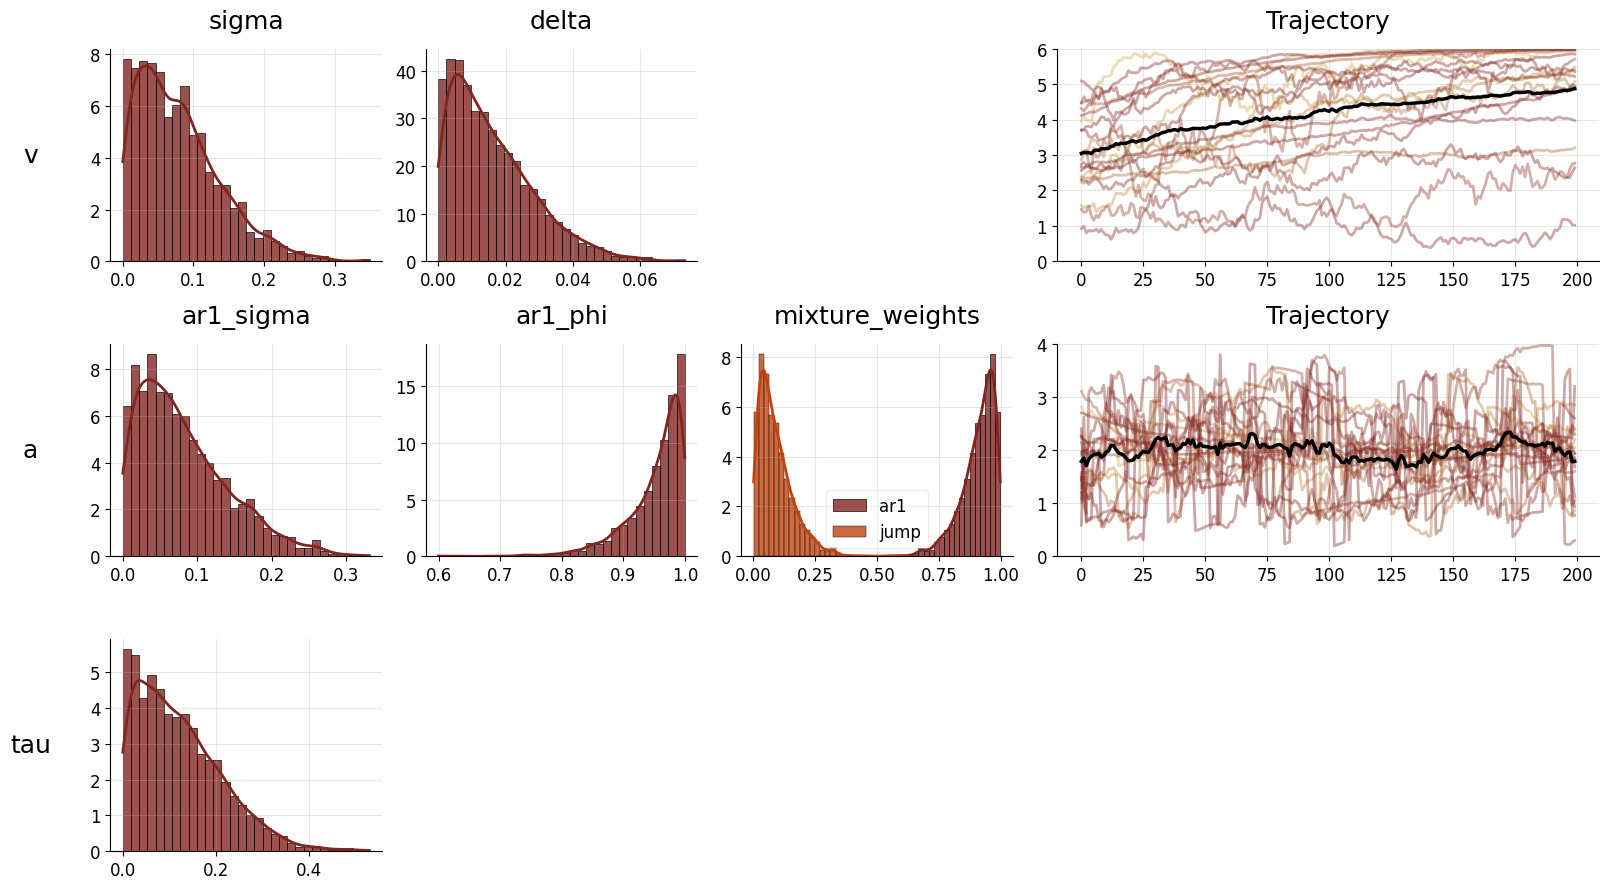

In [6]:
p = joint_prior.plot_joint_prior()

## Specify Generative Model

In [7]:
ddm = sup.simulation.sample_ddm

In [8]:
generative_model = sup.simulation.GenerativeModel(
    prior=joint_prior,
    model=ddm,
)

In [ ]:
# 6 individual trajectories for data dim 0
plot = generative_model.plot_push_forward(
    batch_size=6,
    steps=100,
    data_dim=0,
    type="trajectory",
)

# mean + 95% CI across 500 trajectories
plot = generative_model.plot_push_forward(
    batch_size=500,
    steps=100,
    data_dim=0,
    type="trajectory",
    aggregate=True,
)

# 6 individual RT distributions
plot = generative_model.plot_push_forward(
    batch_size=6,
    steps=200,
    data_dim=0,
    type="hist",
)

# distribution of mean RT across 1000 datasets (default stats_fun)
plot = generative_model.plot_push_forward(
    batch_size=1000,
    steps=200,
    data_dim=0,
    type="hist",
    aggregate=True,
)

# distribution of choice proportions across 1000 datasets (binary dim)
plot = generative_model.plot_push_forward(
    batch_size=1000,
    steps=200,
    data_dim=1,
    type="hist",
    aggregate=True,
    stats_fun=lambda x: x.mean(axis=-1)
)


## Specify Workflow

- Discuss workflow wrapper with Stefan

In [9]:
workflow = sup.workflow.Workflow(
    simulator=generative_model,
    checkpoint_filepath="network_test",
)

Existing checkpoints are not automatically loaded. Upon refitting, the checkpoints will be overwritten.
To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model("network_test/model.keras")


### Offline Training

In [ ]:
workflow.fit_offline(
    train_data_size=20000,
    test_data_size=200,
    steps=500,
    epochs=50,
    batch_size=32
)

In [ ]:
plot = workflow.plot_history()

## Online Training

In [ ]:
workflow.fit_online(
    steps=500,
    epochs=50,
    num_batches_per_epoch=500,
    batch_size=16
)

In [ ]:
plot = workflow.plot_history()

## Validation

### Time-varying Parameters

In [10]:
val_data = workflow.simulator.sample(100, 500)

In [11]:
local_keys = workflow.simulator.local_keys

true = np.stack(
    [val_data[k][..., 0] for k in local_keys],
    axis=-1,
) 

In [14]:
import keras
approximator = keras.saving.load_model("network_test/model.keras")

In [17]:
def sample_posterior(
    approximator,
    data: np.ndarray,
    num_samples: int,
    inference_batch_size: int,
) -> dict:
    """
    Run posterior inference in batches to avoid OOM.

    Parameters
    ----------
    data : np.ndarray, shape (num_datasets, num_steps, data_dims)
    num_samples : int
    inference_batch_size : int

    Returns
    -------
    dict of {param_name: np.ndarray}
    """
    num_datasets = data.shape[0]
    all_samples  = []

    for start in range(0, num_datasets, inference_batch_size):
        end   = min(start + inference_batch_size, num_datasets)
        batch = data[start:end]
        batch_samples = approximator.sample(
            conditions={"data": batch},
            num_samples=num_samples,
        )
        all_samples.append(batch_samples)

    return {
        k: np.concatenate([s[k] for s in all_samples], axis=0)
        for k in all_samples[0].keys()
    }

In [19]:
samples = sample_posterior(
    approximator,
    val_data['data'],
    num_samples=250,
    inference_batch_size=10
)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

In [21]:
estimated = np.concatenate(
    [samples[k] for k in local_keys],
    axis=-1,
)
estimated = estimated.transpose(0, 2, 1, 3)

/scicore/home/rieskamp/schuma0018/GitHub/superstats/examples/../superstats/diagnostics/plots/time_varying_validation.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


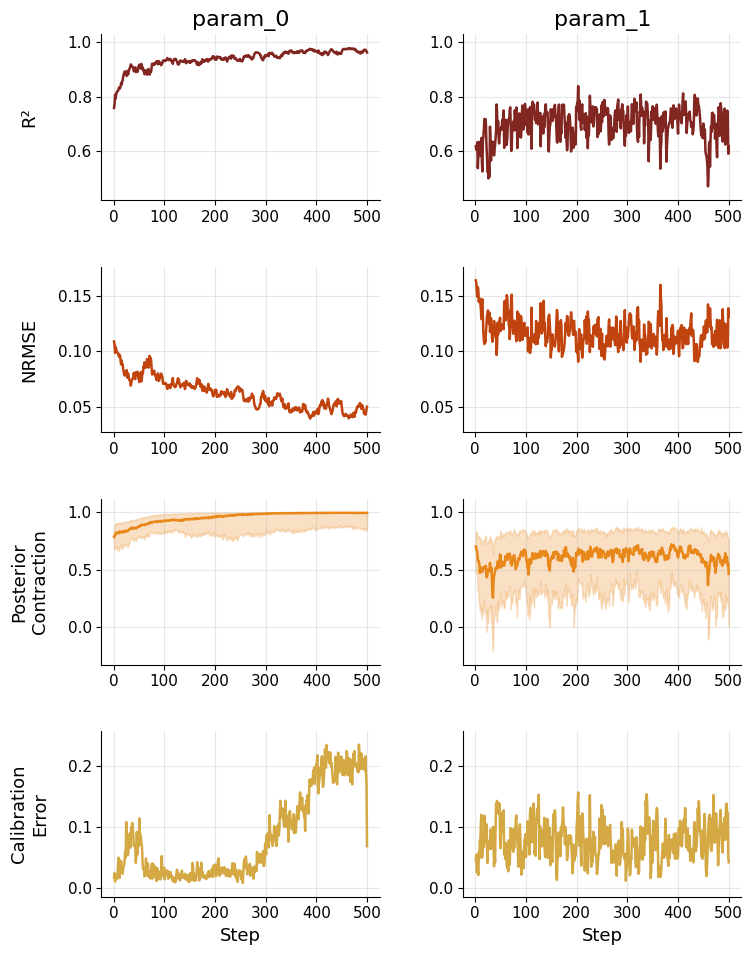

In [22]:
plot = sup.diagnostics.plots.plot_time_varying_validation(true, estimated)

In [ ]:
plot = workflow.validate_time_varying(
    steps=500,
    num_sims=500,
    num_samples=500,
)

### Time-invariant Parameters

In [25]:
time_invariant_keys = workflow.simulator.hyper_keys + workflow.simulator.shared_keys

true = np.stack(
    [val_data[k][..., 0] for k in time_invariant_keys],
    axis=-1,
) 
true.shape

(100, 6)

In [27]:
estimated = np.concatenate(
    [samples[k] for k in time_invariant_keys],
    axis=-1,
)

estimated.shape

(100, 250, 500, 7)

In [ ]:
fig_recovery, fig_calibration = workflow.validate_time_invariant(
    steps=500,
    num_sims=500,
    num_samples=500
)

## Data Fitting